<a href="https://colab.research.google.com/github/MiguelPastorB/pastorbeltra/blob/main/Bernoulli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 1 Parte 1: Problema de los k-brazos: Binomial
- **Alumno:** Pastor Beltrá, Miguel
- **Asignatura:** Extensiones de Machine Learning
- **Curso:** 2025/2026
- **Grupo:** pastorbeltra

**Índice**   
1. [Introducción](#introduccion)
2. [Desarrollo](#desarrollo)
3. [Algoritmos](#algoritmos)
4. [Evaluación](#evaluacion)
5. [Conclusiones](#conclusiones)
6. [Uso de la IA generativa](#ia-generativa)
7. [Bibliografía y referencias](#referencias)

# 1. Introducción <a name="introduccion"></a>

En esta práctica implementamos y comparamos los algoritmos $\epsilon$-greedy, $\epsilon$-decaimiento, UCB1 y Softmax para resolver el dilema de exploración-explotación en un entorno con recompensas Binomiales. A diferencia del caso Bernoulli, aquí cada acción puede generar múltiples éxitos en un número fijo de intentos, lo que introduce mayor variabilidad en las recompensas.

El objetivo es analizar cómo esta estructura afecta el desempeño de los algoritmos, utilizando métricas como la recompensa promedio, el arrepentimiento acumulado y el porcentaje de selección óptima.

# 2. Desarrollo <a name="desarrollo"></a>

Hemos realizado esta práctica en un entorno local utilizando Visual Studio Code. Sin embargo, como especificación del enunciado, el proyecto también está preparado para ejecutarse en Google Colab sin necesidad de configuración adicional. En esta sección tambien incluimos todos los imports necesarios para el correcto funcionamiento del notebook.

## 2.1. Entorno Colab y VSCode

A continuación, incluimos algunas celdas auxiliares para adaptar el entorno de ejecución en Colab, permitiendo acceder correctamente al repositorio y a los módulos del proyecto.

In [ ]:
!rm -r pastorbeltra/
!git clone https://github.com/MiguelPastorB/pastorbeltra.git
%cd pastorbeltra/

In [ ]:
!pip install -r requirements.txt

Esta celda de código añade la carpeta src al path de Python, lo que permite importar correctamente los módulos del proyecto sin necesidad de instalar el paquete.

In [ ]:
%cd k_brazos/

In [2]:
import sys
import os

# Añadimos la carpeta 'src' al path de búsqueda de Python
sys.path.append(os.path.abspath('src'))

## 2.2. Importaciones y semilla

Importamos todas las dependencias necesarias para la ejecución de los experimentos, incluidos los distintos componentes implementados en el proyecto: los algoritmos de aprendizaje ($\epsilon$-greedy, UCB1 y Softmax), las clases que definen los brazos (*arms*) y el entorno *bandit*, así como las funciones de visualización utilizadas para analizar los resultados (recompensa promedio, arrepentimiento y porcentaje de selección óptima).

Finalmente, fijamos una semilla aleatoria (`seed = 2024`) tanto en NumPy como en la librería `random`. Esto garantiza la **reproducibilidad** de los experimentos, permitiendo obtener los mismos resultados en distintas ejecuciones.

In [3]:
# Importamos las librerías necesarias
import numpy as np
import random

# Importamos nuestros algoritmos, brazos y funciones de visualización
from src.algorithms.algorithm import Algorithm
from src.algorithms.epsilon_greedy import EpsilonGreedy, DecayingEpsilonGreedy
from src.algorithms.ucb1 import UCB1
from src.algorithms.softmax import Softmax
from src.arms.arm import Arm
from src.arms.armnormal import ArmNormal
from src.arms.bandit import Bandit
from src.arms.armbinomial import ArmBinomial
from src.plotting.plotting import plot_average_rewards, plot_optimal_selections, plot_regret

# Establecemos una semilla para reproducibilidad
seed = 2024
np.random.seed(seed)
random.seed(seed)

# 3. Algoritmos <a name="algoritmos"></a>

``run_experiment`` simula la interacción de los algoritmos con un bandido k-brazos Binomial, donde cada brazo puede generar múltiples éxitos en un número fijo de intentos.

Para cada algoritmo y paso temporal:

* Seleccionamos un brazo.
* Recibimos la recompensa del entorno (número de éxitos).
* Actualizamos las estimaciones del algoritmo.
* Registramos las métricas: recompensa promedio, % de selección óptima y arrepentimiento acumulado.

Los resultados se promedian sobre todas las ejecuciones para obtener curvas más estables y comparables entre algoritmos.

In [ ]:
def run_experiment(algorithms, n_arms, n_steps, n_runs, n_trials=10):
    """
    Ejecuta el experimento para brazos con Distribución Binomial B(n, p).
    """
    # Matrices para almacenar resultados
    all_rewards = np.zeros((len(algorithms), n_steps))
    optimal_counts = np.zeros((len(algorithms), n_steps))
    regret_accumulated = np.zeros((len(algorithms), n_steps))

    # Definimos las probabilidades p de éxito para cada brazo
    probs = np.linspace(0.1, 0.9, n_arms) 
    
    # IMPORTANTE: En la binomial, la media de cada brazo es n * p 
    means = n_trials * probs
    optimal_arm_idx = np.argmax(means)
    max_mu = means[optimal_arm_idx]

    for run in range(n_runs):
        # Instanciamos los brazos con n > 1 para el estudio binomial
        arms = [ArmBinomial(n=n_trials, p=p) for p in probs]
        bandit = Bandit(arms)
        
        # Reiniciamos algoritmos para cada ejecución independiente
        for alg in algorithms:
            alg.reset() 

        for step in range(n_steps):
            for i, alg in enumerate(algorithms):
                # 1. Selección de acción según la política
                arm_idx = alg.select_arm()
                
                # 2. Obtención de recompensa (número de éxitos en n ensayos)
                reward = bandit.pull_arm(arm_idx)
                
                # 3. Actualización del conocimiento del agente
                alg.update(arm_idx, reward)
                
                # Registro de métricas
                all_rewards[i, step] += reward
                if arm_idx == optimal_arm_idx:
                    optimal_counts[i, step] += 1
                
                # El regret se basa en la diferencia de medias reales (n*p* - n*p_elegido)
                current_regret = max_mu - means[arm_idx]
                regret_accumulated[i, step] += current_regret

    # Promediamos resultados para obtener curvas suaves
    avg_rewards = all_rewards / n_runs
    avg_optimal = (optimal_counts / n_runs) * 100 
    avg_regret = np.cumsum(regret_accumulated / n_runs, axis=1) 

    return avg_rewards, avg_optimal, avg_regret

# 4. Evaluación

En esta sección ejecutamos los experimentos para analizar y comparar el desempeño de los algoritmos en un entorno bandido k-brazos Binomial, donde cada brazo devuelve una recompensa discreta correspondiente al número de éxitos en ``n_trials`` ensayos $B(n, p)$.

Definimos los parámetros del experimento:

* **n_arms = 10:** número de brazos disponibles.
* **n_steps = 1000:** pasos de interacción por ejecución.
* **n_runs = 2000:** ejecuciones independientes para obtener curvas más estables.
* **n_trials = 10:** número de ensayos por brazo, de modo que cada recompensa siga una distribución binomial $B(n=10, p)$.

Instanciamos los algoritmos a comparar:

* **$\epsilon$-greedy:** con $\epsilon$ =0.1.
* **$\epsilon$-decaimiento:** reduce $\epsilon$ a lo largo del tiempo.
* **UCB1:** equilibra exploración y explotación según la incertidumbre.
* **Softmax:** con temperatura ajustada a 1.0 para compensar la mayor magnitud de las recompensas.



In [5]:
# Parámetros del experimento
n_arms = 10
n_steps = 1000
n_runs = 2000 
n_trials = 10  # Cada brazo es una Binomial B(n=10, p)

# Lista de algoritmos a comparar
# Ajustamos la temperatura de Softmax proporcionalmente al valor de n_trials
all_algorithms = [
    EpsilonGreedy(k=n_arms, epsilon=0.1),
    DecayingEpsilonGreedy(k=n_arms),
    UCB1(k=n_arms),
    Softmax(k=n_arms, temperature=1.0) # Subimos a 1.0 porque las recompensas son x10
]

# Ejecutamos
avg_rewards, opt_selections, regret_data = run_experiment(all_algorithms, n_arms, n_steps, n_runs, n_trials=n_trials)

En esta gráfica, hemos observado un gran dominio por parte del algoritmo UCB1 ($c=1$), el cual alcanza la recompensa máxima de $9.0$ (correspondiente al brazo con $p=0.9$) de forma casi instantánea. $\epsilon$-greedy ($\epsilon=0.1$) muestra una progresión sólida pero se estabiliza por debajo de UCB1 (en torno a $8.6$), mientras que Softmax ($temp=1.0$) presenta una convergencia mucho más lenta, alcanzando apenas el valor de $8.2$. Por su parte, el $\epsilon$-decaimiento comienza con una exploración inicial alta, su curva es puramente ascendente y termina superando ligeramente a Epsilon-Greedy, a pesar de haber ido por detrás la mayor parte del experimento.

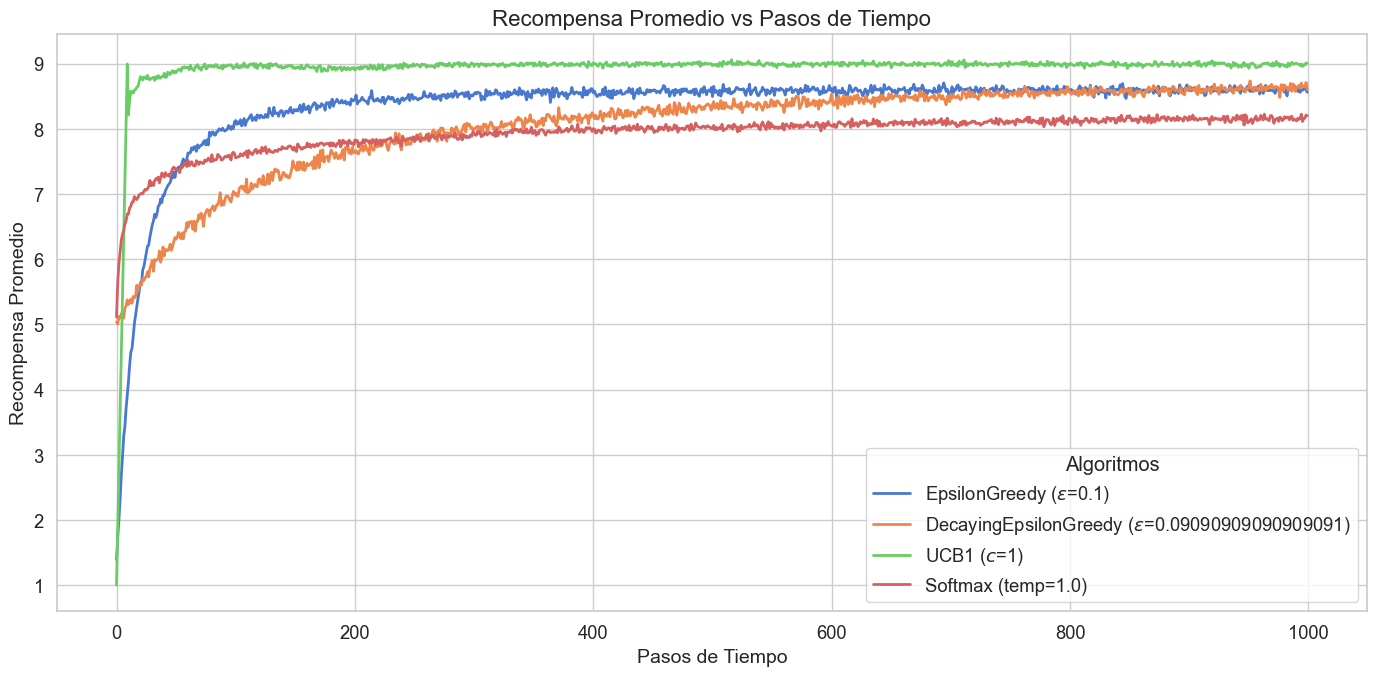

In [6]:
# Gráfica 1: Recompensa Promedio (Verás que el máximo ronda los 9.0, que es n * p_max)
plot_average_rewards(n_steps, avg_rewards, all_algorithms)

Hemos identificado un comportamiento muy bueno en UCB1, que logra una precisión cercana al 100% de selección óptima en menos de 100 pasos. Esto se debe a que, con $n=10$ ensayos por paso, la incertidumbre sobre la media se reduce mucho más rápido, permitiendo que el término de confianza de UCB1 sea muy preciso. $\epsilon$-greedy se estabiliza en un 91%, lo cual es coherente con su política (explora el 10% de las veces, repartiendo esa probabilidad entre los 10 brazos). Softmax muestra una trayectoria ascendente muy pobre, terminando apenas en el 45%, evidenciando que la temperatura de $1.0$ no es lo suficientemente agresiva para este entorno. Por otro lado, hemos observado que el $\epsilon$-decaimiento presenta una progresión ascendente muy sólida, aunque parte del 0% debido a su exploración total inicial, logra cruzar la línea del $\epsilon$-greedy fijo cerca del paso 800, terminando en un 93% de precisión.

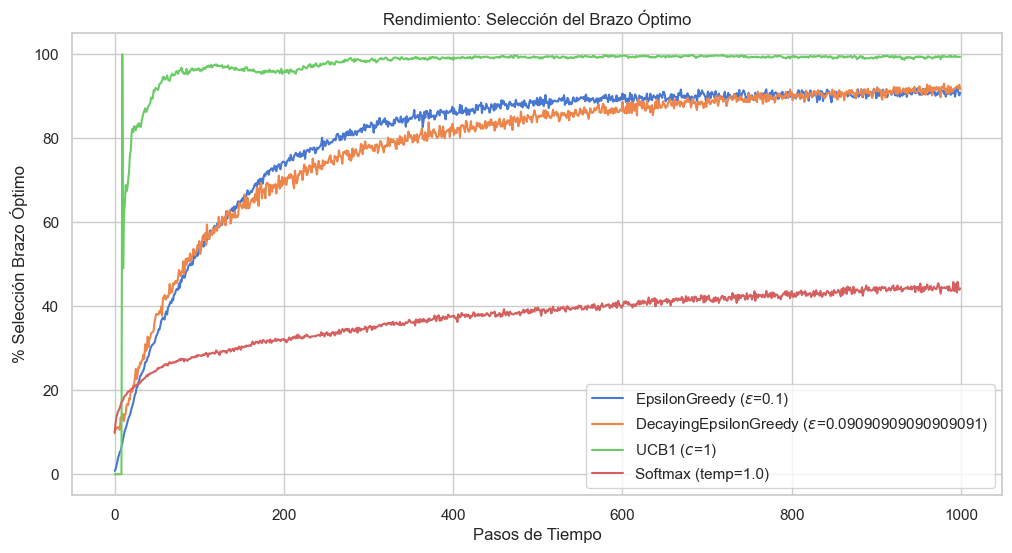

In [7]:
# Gráfica 2: % de Selección del Brazo Óptimo
plot_optimal_selections(n_steps, opt_selections, all_algorithms)

La curva de UCB1 es prácticamente horizontal tras el descubrimiento inicial, lo que nos confirma que es el algoritmo más eficiente en este escenario. En contraste, tanto $\epsilon$-greedy como Softmax muestran un crecimiento lineal del rechazo, esto sucede porque nunca dejan de tomar decisiones no tan óptimas debido a su exploración residual. Por otra parte, en el $\epsilon$-decaimiento comienza con una pendiente muy pronunciada debido al alto coste de su exploración inicial agresiva, pero a medida que avanza el tiempo, la curva es más pronunciada. Esto nos demuestra que el algoritmo logra reducir su error sistemático conforme disminuye su parámetro de exploración, volviéndose más eficiente a largo plazo.

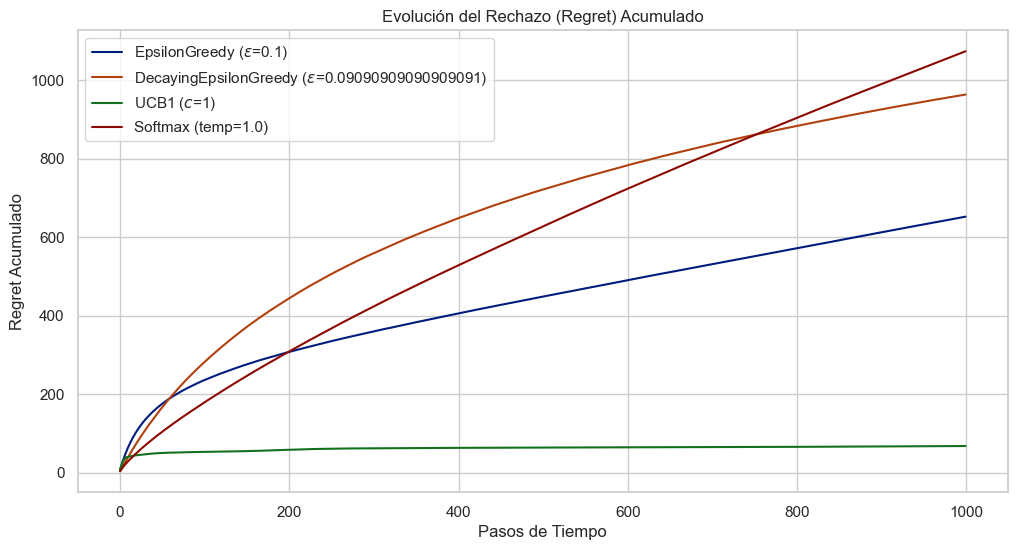

In [8]:
# Gráfica 3: Regret Acumulado
plot_regret(n_steps, regret_data, all_algorithms)

# 5. Conclusiones <a name="conclusiones"></a>

Tras analizar los resultados, concluimos lo siguiente:

* **$\epsilon$-greedy:** en problemas binomiales, un valor de $\epsilon=0.1$ sigue siendo un estándar robusto, logrando una precisión del 91%. Sin embargo, su arrepentimiento crece de forma lineal, lo que en entornos de larga duración supone una ineficiencia que UCB1 logra evitar.

* **$\epsilon$-decaimiento:** hemos comprobado que este método mejora a largo plazo. Aunque acumula mucho rechazo al principio (debido a su exploración total), su capacidad para reducir la exploración gradualmente le permite terminar con una precisión superior al método $\epsilon$-greedy (93% vs 91%). Concluimos que es ideal si el objetivo es maximizar el rendimiento a largo plazo.

* **UCB1:** hemos comprobado que UCB1 es el mejor algoritmo para este escenario. La mayor cantidad de información por cada acción ($n=10$) permite que los intervalos de confianza se estrechen rápidamente. Esto elimina la necesidad de exploración aleatoria casi desde el inicio, logrando un arrepentimiento casi nulo y una precisión perfecta del 100%.

* **Softmax:** observamos que Softmax sufre significativamente con el cambio de escala de recompensas (de 1 a 10). Con una temperatura de $1.0$, la diferencia entre las opciones no es lo bastante pronunciada para que el algoritmo sea agresivo, lo que resulta en una convergencia lenta y una precisión pobre (45%).

# 6. Uso de la IA generativa <a name="ia-generativa"></a>

Nada.

# 7. Bibliografía y referencias <a name="referencias"></a>

* Profesor/a [Hernández Molinero], [LD]. (2026). Material de aula virtual y clases de Extensiones de Machine Learning. Universidad de Murcia.